In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.3.0
    Uninstalling typeguard-4.3.0:
      Successfully uninstalled typeguard-4.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

!unzip "/content/drive/MyDrive/Sunflower.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Sunflower/anomaly/image1264.jpg  
  inflating: Sunflower/anomaly/image1265.jpg  
  inflating: Sunflower/anomaly/image127.jpg  
  inflating: Sunflower/anomaly/image1270.jpg  
  inflating: Sunflower/anomaly/image1272.jpg  
  inflating: Sunflower/anomaly/image1273.jpg  
  inflating: Sunflower/anomaly/image1277.jpg  
  inflating: Sunflower/anomaly/image1279.jpg  
  inflating: Sunflower/anomaly/image1280.jpg  
  inflating: Sunflower/anomaly/image1282.jpg  
  inflating: Sunflower/anomaly/image1283.jpg  
  inflating: Sunflower/anomaly/image1289.jpg  
  inflating: Sunflower/anomaly/image129.jpg  
  inflating: Sunflower/anomaly/image1298.jpg  
  inflating: Sunflower/anomaly/image13.jpg  
  inflating: Sunflower/anomaly/image1301.jpg  
  inflating: Sunflower/anomaly/image1303.jpg  
  inflating: Sunflower/anomaly/image1305.jpg  
  inflating: Sunflower/anomaly/image1307.jpg  
  inflating: Sunflower/anomaly/image1309.jpg  
  inflating: 

In [4]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Sunflower/Downy mildew'
target_dir = '/content/data'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/data/Downy mildew'

In [5]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Sunflower/Fresh Leaf'
target_dir = '/content/data'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/data/Fresh Leaf'

In [6]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Sunflower/Gray mold'
target_dir = '/content/data'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/data/Gray mold'

In [7]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Sunflower/Leaf scars'
target_dir = '/content/data'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/data/Leaf scars'

In [8]:
base_dir = "/content/data"

In [9]:
# prompt: image counts of each folders and subfolders

import os

def count_images(root_directory):
  """
  Counts the number of images in a directory and its subdirectories.

  Args:
    root_directory: The root directory to count images in.

  Returns:
    A dictionary where the keys are the subdirectories and the values are the number of images in each subdirectory.
  """

  image_counts = {}

  for subdirectory in os.listdir(root_directory):
    subdirectory_path = os.path.join(root_directory, subdirectory)

    if os.path.isdir(subdirectory_path):
      image_count = 0

      for file_name in os.listdir(subdirectory_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
          image_count += 1

      image_counts[subdirectory] = image_count

  return image_counts

# Example usage
root_directory = '/content/data'
image_counts = count_images(root_directory)

for subdirectory, count in image_counts.items():
  print(f"Subdirectory: {subdirectory}, Image count: {count}")


Subdirectory: Gray mold, Image count: 72
Subdirectory: Leaf scars, Image count: 140
Subdirectory: Fresh Leaf, Image count: 134
Subdirectory: Downy mildew, Image count: 120


In [10]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['Gray mold', 'Leaf scars', 'Fresh Leaf', 'Downy mildew']


In [11]:
len(folders)

4

In [12]:
# prompt: show image height and width

# Assuming 'image_path' is the path to your image
image_path = '/content/data/Downy mildew/downymildew.  (1).jpg'  # Replace with the actual path
img = image.load_img(image_path)
width, height = img.size
print("Image Width:", width)
print("Image Height:", height)


Image Width: 3120
Image Height: 4160


In [13]:
from PIL import Image
import os

def resize_images(input_folder, output_folder, target_size=(224, 224)):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through all subfolders in the input folder
    for subfolder in os.listdir(input_folder):
        subfolder_path = os.path.join(input_folder, subfolder)
        if os.path.isdir(subfolder_path):  # Check if it's a directory
            output_subfolder = os.path.join(output_folder, subfolder)
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)
            # Loop through all files in the subfolder
            for filename in os.listdir(subfolder_path):
                # Check if the file is an image
                if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                    # Open the image file
                    with Image.open(os.path.join(subfolder_path, filename)) as img:
                        # Resize the image
                        resized_img = img.resize(target_size)
                        # Save the resized image to the output folder
                        resized_img.save(os.path.join(output_subfolder, filename))

# Specify the input and output folders
input_folder = "/content/data"
output_folder = '/content/resize'

# Call the function to resize images
resize_images(input_folder, output_folder)

In [14]:
base_dir = "/content/resize"

In [15]:
import os
import cv2

def invert_colors(input_folder, output_folder):
    # Iterate through all files and folders recursively
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            # Check if the file is an image
            if file.lower().lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                # Create input and output file paths
                input_image_path = os.path.join(root, file)
                output_image_path = os.path.join(output_folder, os.path.relpath(input_image_path, input_folder))

                # Read the image
                image = cv2.imread(input_image_path)

                # Invert the colors
                inverted_image = ~image

                # Ensure the output directory exists
                os.makedirs(os.path.dirname(output_image_path), exist_ok=True)

                # Save the inverted image
                cv2.imwrite(output_image_path, inverted_image)

# Example usage:
input_folder = "/content/resize"
output_folder = "/content/Invert"
invert_colors(input_folder, output_folder)


In [16]:
base_dir = "/content/Invert"

In [17]:
import numpy as np
import sys

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)
    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-10, 10)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.2)),  # brightness
            iaa.LinearContrast((0.8, 1.2))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 2000
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented2', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)

Augmenting images in /content/Invert/Gray mold: 100%|██████████| 72/72 [00:08<00:00,  8.79it/s]


Augmentation complete for /content/Invert/Gray mold. Total images in '/content/augmented2/Gray mold': 2000


Augmenting images in /content/Invert/Leaf scars: 100%|██████████| 140/140 [00:06<00:00, 21.22it/s]


Augmentation complete for /content/Invert/Leaf scars. Total images in '/content/augmented2/Leaf scars': 2000


Augmenting images in /content/Invert/Fresh Leaf: 100%|██████████| 134/134 [00:07<00:00, 17.18it/s]


Augmentation complete for /content/Invert/Fresh Leaf. Total images in '/content/augmented2/Fresh Leaf': 2000


Augmenting images in /content/Invert/Downy mildew: 100%|██████████| 120/120 [00:06<00:00, 19.00it/s]

Augmentation complete for /content/Invert/Downy mildew. Total images in '/content/augmented2/Downy mildew': 2000


In [18]:
base_dir="/content/augmented2"

In [19]:

import os
import cv2
import numpy as np

# Function to detect outliers using Modified Z-score method with Median Absolute Deviation (MAD)
def detect_outliers_mad(data, threshold=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    modified_z_scores = 0.6745 * (data - median) / mad
    outliers = np.abs(modified_z_scores) > threshold
    return outliers

# Function to handle outliers in an image using Modified Z-score with MAD
def handle_outliers(image):
    # Flatten the image into a 1D array
    flattened_image = image.flatten()
    # Detect outliers using Modified Z-score with MAD
    outliers = detect_outliers_mad(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(outliers, median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(image.shape)
    return cleaned_image

# Root directory
root_dir = base_dir

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers using Modified Z-score with MAD
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)

<ipython-input-19-129410934d08>:9: RuntimeWarning: divide by zero encountered in divide
  modified_z_scores = 0.6745 * (data - median) / mad
<ipython-input-19-129410934d08>:9: RuntimeWarning: invalid value encountered in divide
  modified_z_scores = 0.6745 * (data - median) / mad


Streaming output truncated to the last 5000 lines.
Cleaned image saved at: /content/augmented2/Fresh Leaf/aug_6_fresh. (61).jpg
Processing file: aug_2_fresh. (65).jpg
Cleaned image saved at: /content/augmented2/Fresh Leaf/aug_2_fresh. (65).jpg
Processing file: aug_4_fresh. (72).jpg
Cleaned image saved at: /content/augmented2/Fresh Leaf/aug_4_fresh. (72).jpg
Processing file: aug_9_fresh. (34).jpg
Cleaned image saved at: /content/augmented2/Fresh Leaf/aug_9_fresh. (34).jpg
Processing file: aug_4_fresh. (15).jpg
Cleaned image saved at: /content/augmented2/Fresh Leaf/aug_4_fresh. (15).jpg
Processing file: aug_4_fresh. (123).jpg
Cleaned image saved at: /content/augmented2/Fresh Leaf/aug_4_fresh. (123).jpg
Processing file: orig_fresh. (68).jpg
Cleaned image saved at: /content/augmented2/Fresh Leaf/orig_fresh. (68).jpg
Processing file: aug_8_fresh. (23).jpg
Cleaned image saved at: /content/augmented2/Fresh Leaf/aug_8_fresh. (23).jpg
Processing file: orig_fresh. (87).jpg
Cleaned image saved at

In [20]:
len(folders)

4

In [21]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [22]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [23]:

size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 5600 images belonging to 4 classes.
Found 1200 images belonging to 4 classes.
Found 1200 images belonging to 4 classes.


In [24]:
test_labels = np.array(test_generator.labels)

In [33]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionV3  # Import InceptionV3 instead of NASNetMobile

# Custom GroupNormalization layer
class GroupNormalization(layers.Layer):
    def __init__(self, groups=32, **kwargs):
        super(GroupNormalization, self).__init__(**kwargs)
        self.groups = groups

    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],),
                                     initializer='ones', trainable=True)
        self.offset = self.add_weight(name='offset', shape=(input_shape[-1],),
                                      initializer='zeros', trainable=True)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        group_shape = tf.concat([input_shape[:-1], [self.groups, input_shape[-1] // self.groups]], axis=0)
        grouped_inputs = tf.reshape(inputs, group_shape)
        mean, variance = tf.nn.moments(grouped_inputs, [1, 2], keepdims=True)
        normalized_inputs = (grouped_inputs - mean) / tf.sqrt(variance + 1e-5)
        normalized_inputs = tf.reshape(normalized_inputs, input_shape)
        return normalized_inputs * self.scale + self.offset

# Define a simple SqueezeNet architecture
def SqueezeNet(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv2D(96, (7, 7), strides=(2, 2), padding='same')(inputs)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(128, (1, 1), padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)
    x = layers.Conv2D(128, (1, 1), padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)

    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(256, (1, 1), padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)
    x = layers.Conv2D(512, (3, 3), padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)

    x = layers.Conv2D(256, (1, 1), padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)

    x = layers.Conv2D(256, (1, 1), padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.relu(z))(x)

    return Model(inputs, x)

# Define the model creation function
def create_model(input_shape, num_classes):
    InceptionV3_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))

    SqueezeNet_model = SqueezeNet(input_shape)

    input_layer = Input(shape=input_shape)
    InceptionV3_features = InceptionV3_model(input_layer)
    SqueezeNet_features = SqueezeNet_model(input_layer)

    # Global average pooling for feature extraction
    InceptionV3_pooled = layers.GlobalAveragePooling2D()(InceptionV3_features)
    SqueezeNet_pooled = layers.GlobalAveragePooling2D()(SqueezeNet_features)

    combined_features = layers.Concatenate()([InceptionV3_pooled, SqueezeNet_pooled])

    # Add GroupNormalization and Dense layers
    x = Flatten()(combined_features)
    x = GroupNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = GroupNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = GroupNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    return model

# Define the input shape and number of classes
input_shape = (224, 224, 3)  # Example input shape
num_classes = 4  # Example number of classes

# Create the model
model = create_model(input_shape, num_classes)

# Display the model summary
model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20            │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ inception_v3 (Functional) │ (None, 5, 5, 2048)     │     21,802,784 │ input_layer_20[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_12             │ (None, 28, 28, 256)    │      1,764,992 │ input_layer_20[0][0]   │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 2048)           │              0 │ inception_v3[0][0]     │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 256)            │              0 │ functional_12[0][0]    │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_16            │ (None, 2304)           │              0 │ global_average_poolin… │
│ (Concatenate)             │                        │                │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_6 (Flatten)       │ (None, 2304)           │              0 │ concatenate_16[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ group_normalization_18    │ (None, 2304)           │          4,608 │ flatten_6[0][0]        │
│ (GroupNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_24 (Dense)          │ (None, 128)            │        295,040 │ group_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_18 (Dropout)      │ (None, 128)            │              0 │ dense_24[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ group_normalization_19    │ (None, 128)            │            256 │ dropout_18[0][0]       │
│ (GroupNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_25 (Dense)          │ (None, 128)            │         16,512 │ group_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_19 (Dropout)      │ (None, 128)            │              0 │ dense_25[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ group_normalization_20    │ (None, 128)            │            256 │ dropout_19[0][0]       │
│ (GroupNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_26 (Dense)          │ (None, 128)            │         16,512 │ group_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_20 (Dropout) 

 Total params: 23,901,988 (91.18 MB)

 Trainable params: 23,867,300 (91.05 MB)

 Non-trainable params: 34,688 (135.50 KB)

In [34]:
input_shape = (224, 224, 3)
num_classes = 4

# Create the model
model = create_model(input_shape, num_classes)

import tensorflow as tf

def weighted_categorical_crossentropy(weights):
    """
    Weighted categorical crossentropy for multi-class classification.

    Args:
        weights (list or array): A list or array with 4 elements for the weights of each class.

    Returns:
        loss (function): A function that computes the weighted categorical crossentropy loss.
    """
    def loss(y_true, y_pred):
        # Clip predictions to prevent NaN errors
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())

        # Calculate unweighted categorical crossentropy
        unweighted_loss = y_true * tf.math.log(y_pred)

        # Multiply by class weights
        weighted_loss = unweighted_loss * tf.constant(weights, dtype=tf.float32)

        # Sum the loss for each class and take the mean
        return -tf.reduce_mean(tf.reduce_sum(weighted_loss, axis=-1))

    return loss

weights = [0.5, 1.0, 1.5, 2.0]  # Example weights for the 4 classes


optim = keras.optimizers.AdamW(
    learning_rate=0.0001,
    weight_decay=0.006,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=True,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="adamw"
)

optimizer = optim
model.compile(optimizer=optimizer, loss=weighted_categorical_crossentropy(weights), metrics=['accuracy'])



In [35]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.4672 - loss: 1.5949 - val_accuracy: 0.7375 - val_loss: 0.4250 - learning_rate: 1.0000e-04
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 96s 621ms/step - accuracy: 0.7925 - loss: 0.4452 - val_accuracy: 0.9042 - val_loss: 0.1474 - learning_rate: 1.0000e-04
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 84s 650ms/step - accuracy: 0.9069 - loss: 0.2078 - val_accuracy: 0.9733 - val_loss: 0.0608 - learning_rate: 1.0000e-04
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 59s 656ms/step - accuracy: 0.9605 - loss: 0.1119 - val_accuracy: 0.9817 - val_loss: 0.0414 - learning_rate: 1.0000e-04
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 59s 661ms/step - accuracy: 0.9827 - loss: 0.0664 - val_accuracy: 0.9883 - val_loss: 0.0314 - learning_rate: 1.0000e-04
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 59s 658ms/step - accuracy: 0.9853 - loss: 0.0501 - val_accuracy: 0.9858 - val_loss: 0.0611 - learning_rate: 1.0000e-04
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accura

In [36]:
test_loss, test_accuracy = model.evaluate(val_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.9756 - loss: 0.0542
Test Loss: 0.0314
Test Accuracy: 0.9883


<Figure size 640x480 with 0 Axes>

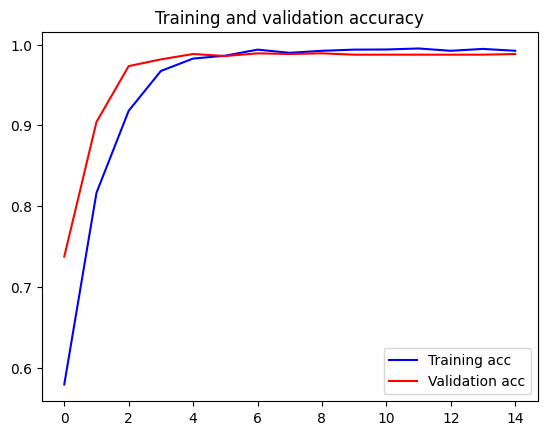

<Figure size 640x480 with 0 Axes>

In [37]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

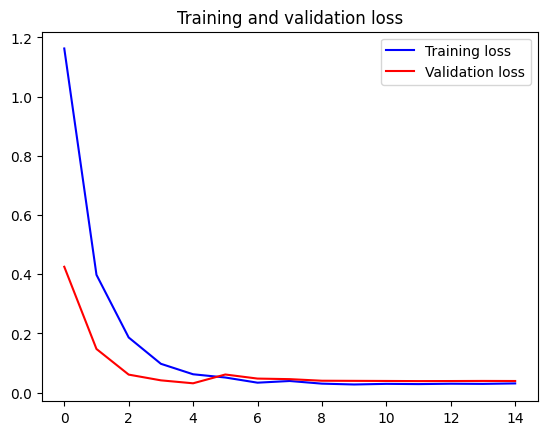

In [38]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 527ms/step


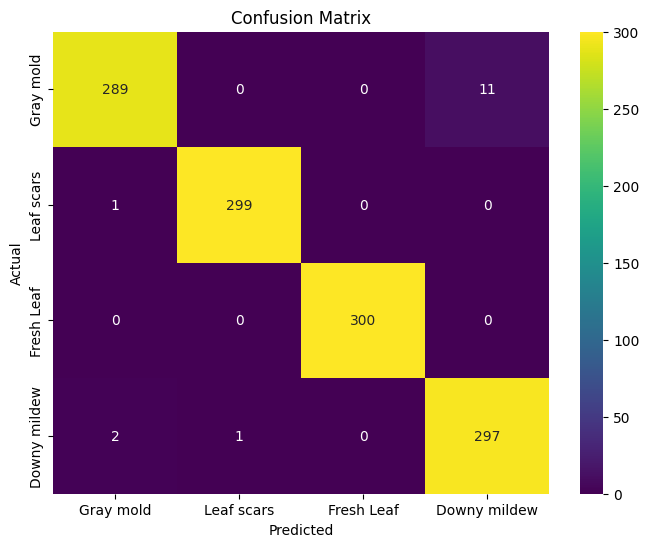

Precision: 1.0
Recall: 0.9966666666666667
F1 Score: 0.9983305509181971


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step


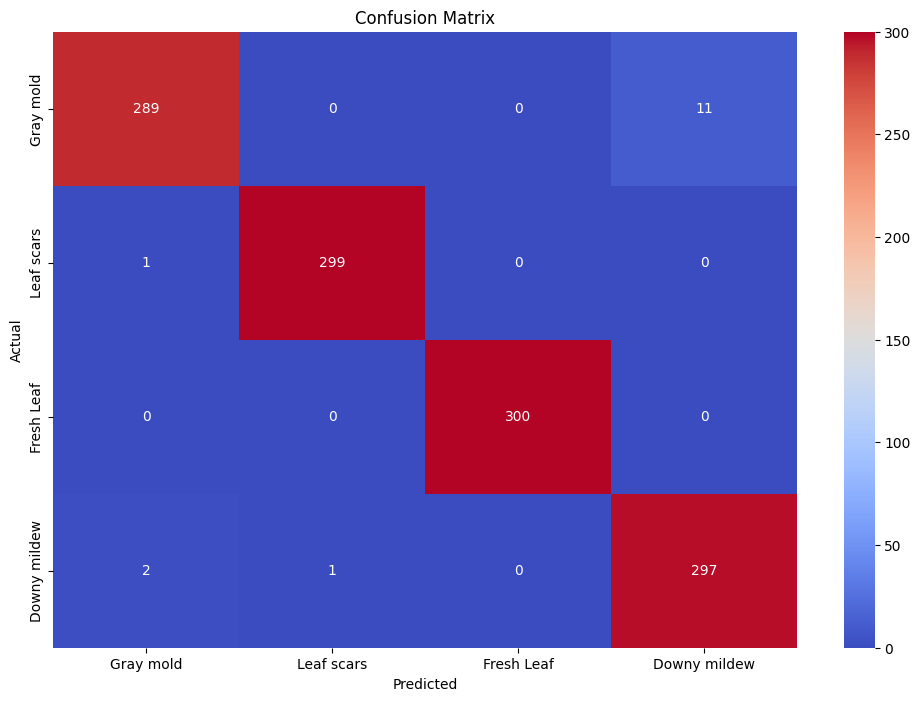

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



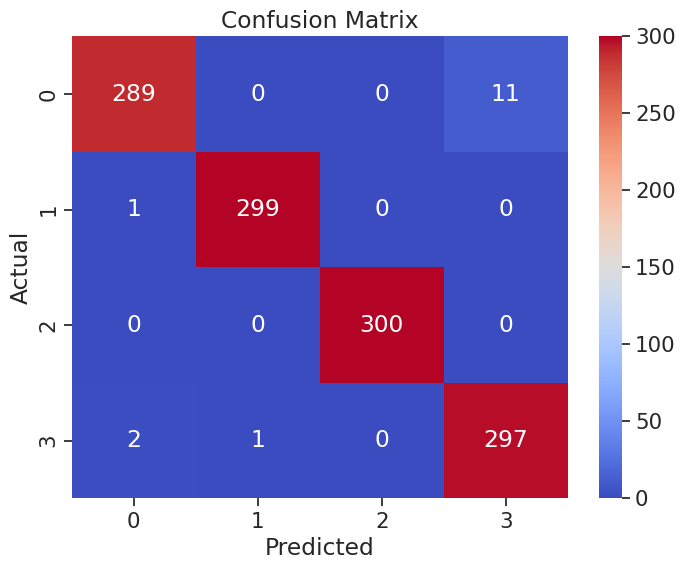

In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


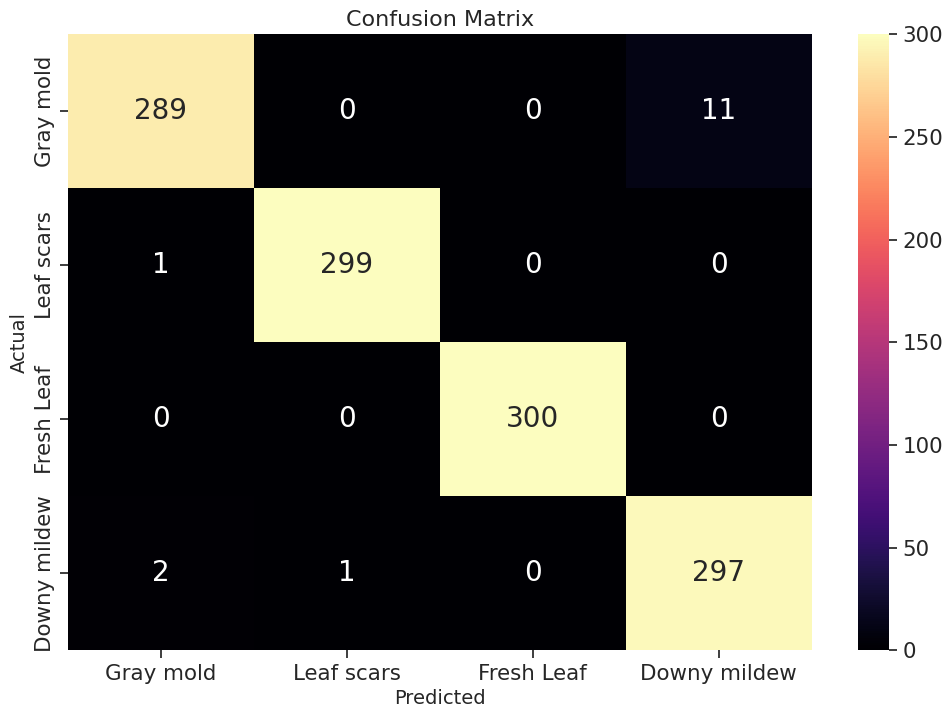

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [43]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

In [44]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.99      0.96      0.98       300
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00       300
           3       0.96      0.99      0.98       300

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



<Figure size 640x480 with 0 Axes>

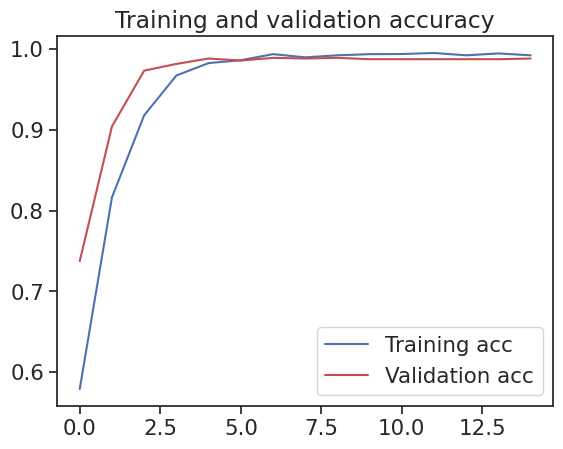

<Figure size 640x480 with 0 Axes>

In [45]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

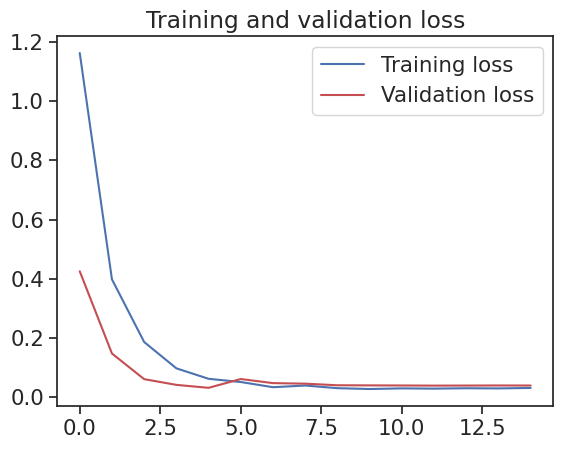

In [46]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

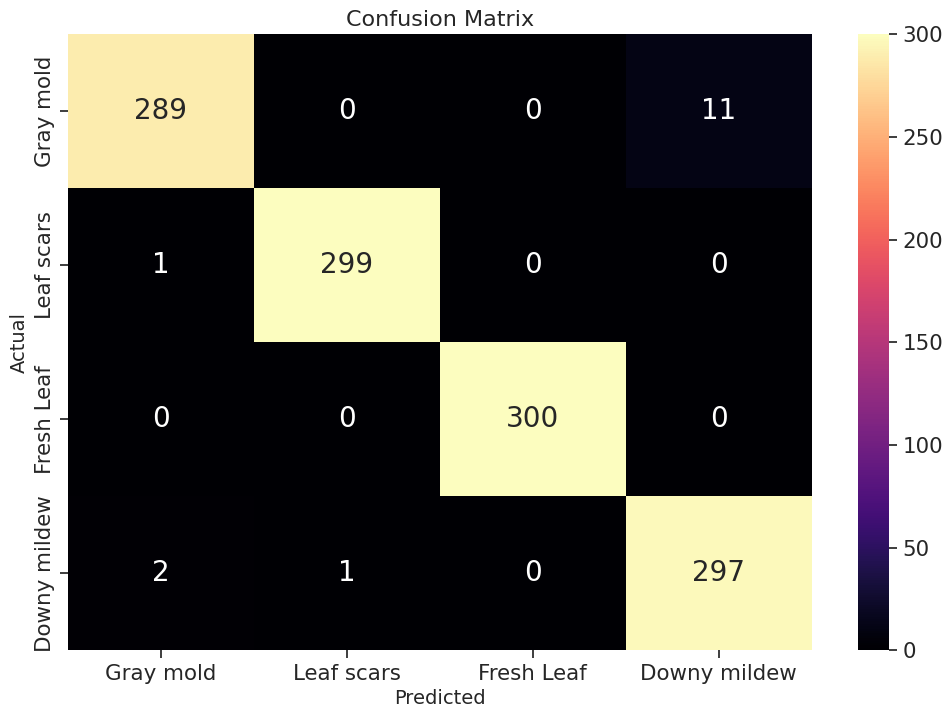

In [47]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step


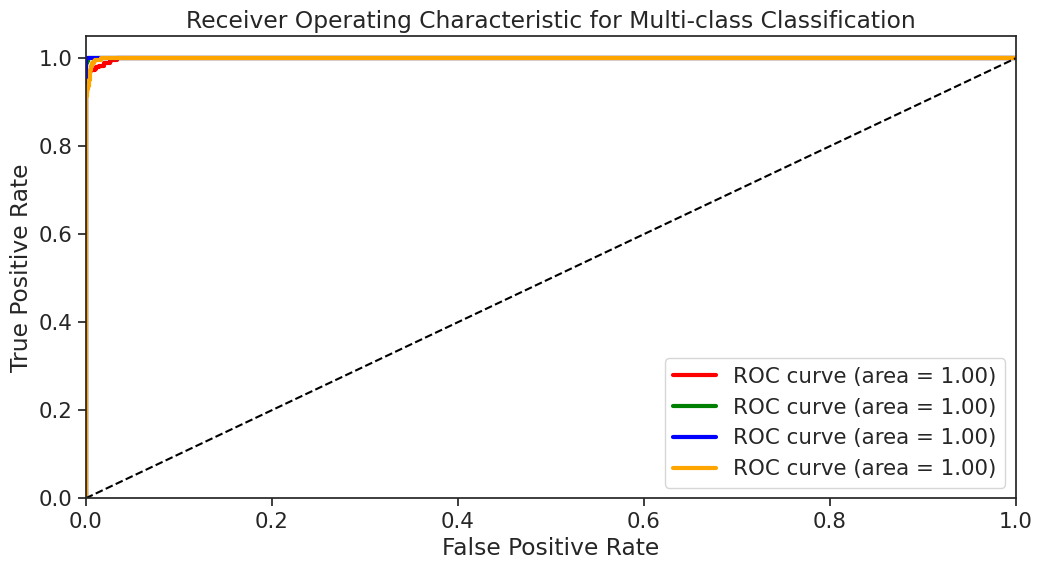

AUC scores:
Class 1: 0.9993666666666667
Class 2: 0.9999814814814815
Class 3: 1.0
Class 4: 0.9996


In [48]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 4  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange', 'pink', 'yellow', 'purple', 'cyan']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


In [49]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step
Class Gray mold:
Precision: 0.9897
Recall: 0.9633
F1-score: 0.9764

Class Leaf scars:
Precision: 0.9967
Recall: 0.9967
F1-score: 0.9967

Class Fresh Leaf:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class Downy mildew:
Precision: 0.9643
Recall: 0.9900
F1-score: 0.9770



In [50]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step
              precision    recall  f1-score   support

   Gray mold       0.99      0.96      0.98       300
  Leaf scars       1.00      1.00      1.00       300
  Fresh Leaf       1.00      1.00      1.00       300
Downy mildew       0.96      0.99      0.98       300

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



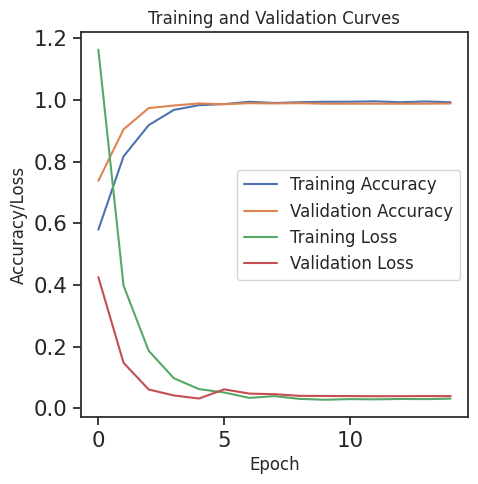

In [51]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progress.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progress.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progress.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progress.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step


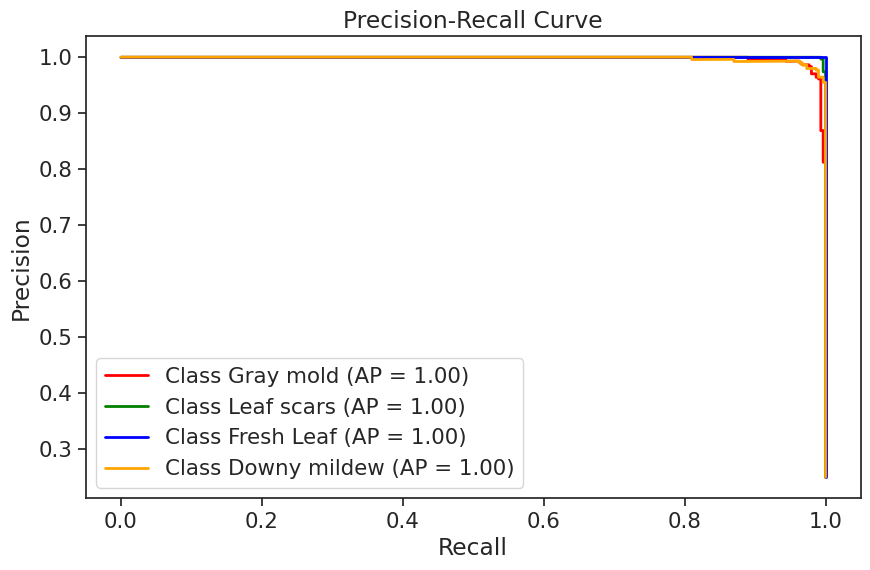

In [52]:
# prompt: create PR curve

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Get predicted probabilities for each class
y_probs = model.predict(test_generator)

# Get the true labels
y_true = test_generator.classes

# Calculate precision-recall curve and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

n_classes = len(classes)

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        (y_true == i).astype(int), y_probs[:, i]
    )
    average_precision[i] = average_precision_score(
        (y_true == i).astype(int), y_probs[:, i]
    )

# Plot the PR curve for each class
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue', 'orange', 'pink', 'yellow', 'purple', 'cyan']
for i, color in zip(range(n_classes), colors):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        color=color,
        label=f"Class {classes[i]} (AP = {average_precision[i]:.2f})",
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


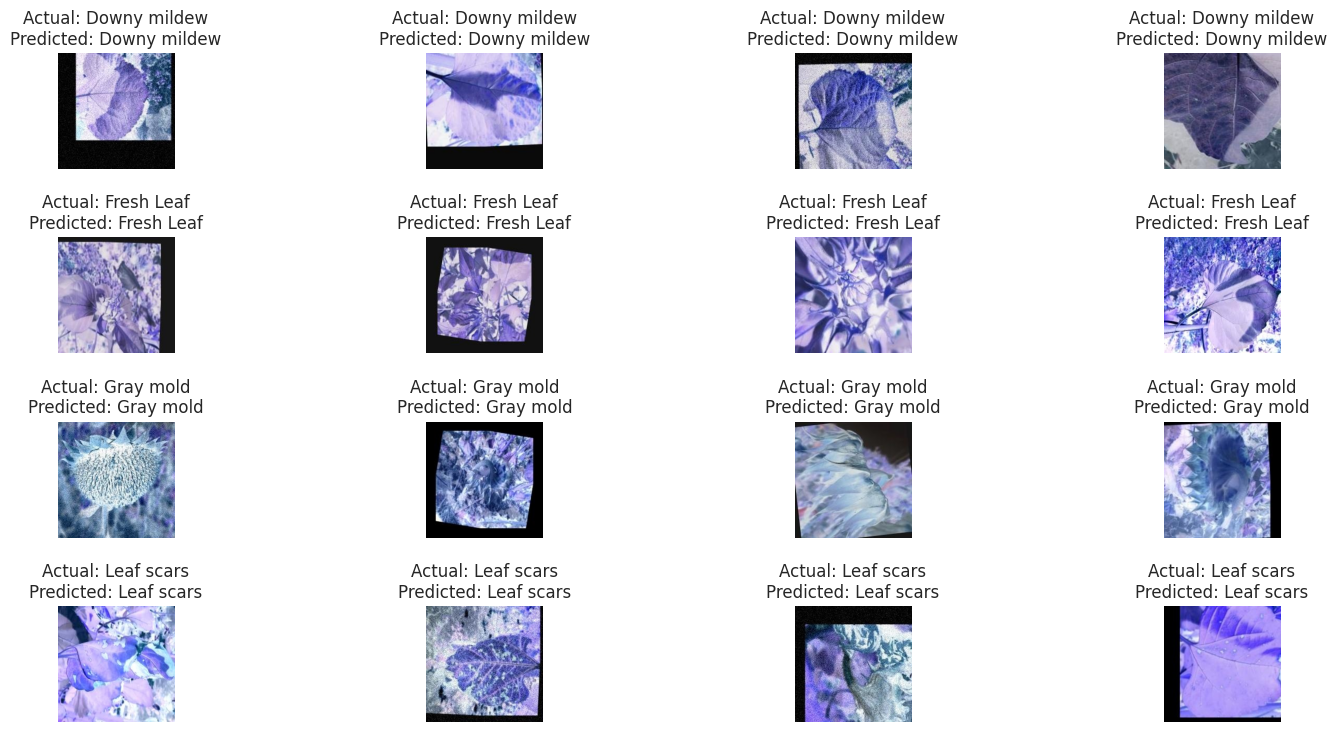

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Assuming test_generator is your test data generator and model is your trained model

# Number of classes and images per class
num_classes = 4
num_images_per_class = 4
num_images_to_display = num_classes * num_images_per_class

# Reset the test generator to the start
test_generator.reset()

# Get the class names from the test generator
class_names = list(test_generator.class_indices.keys())

# Initialize lists to store images and labels
images_to_display = []
labels_to_display = []

# Dictionary to track the number of images collected per class
collected_counts = {class_name: 0 for class_name in class_names}

# Loop to collect images from each class
while len(images_to_display) < num_images_to_display:
    images, labels = next(test_generator)
    indices = list(range(len(images)))
    random.shuffle(indices)  # Shuffle indices to select random images

    for i in indices:
        class_index = np.argmax(labels[i])  # Get the class index
        class_label = class_names[class_index]  # Get the class name

        # Check if we've already collected enough images for this class
        if collected_counts[class_label] < num_images_per_class:
            images_to_display.append(images[i])
            labels_to_display.append(labels[i])
            collected_counts[class_label] += 1

        # Stop if we've collected enough images
        if len(images_to_display) >= num_images_to_display:
            break

# Convert the lists to numpy arrays
images_to_display = np.array(images_to_display)
labels_to_display = np.array(labels_to_display)

# Make predictions for the selected images
predictions = model.predict(images_to_display)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(labels_to_display, axis=1)

# Plot the images with actual and predicted labels
plt.figure(figsize=(15, 15))  # Adjust figure size
for i in range(num_images_to_display):
    plt.subplot(8, 4, i + 1)  # 8 rows and 4 columns to accommodate 32 images
    plt.imshow(images_to_display[i])
    plt.title(f"Actual: {class_names[true_labels[i]]}\nPredicted: {class_names[predicted_labels[i]]}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [54]:
# Reset the test generator to start
test_generator.reset()

# Generate predictions on the entire test set
predictions = model.predict(test_generator)

# Get the true labels for the entire test set
test_labels = test_generator.classes

# Convert predictions to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Calculate the confusion matrix and performance metrics
cm = confusion_matrix(test_labels, predicted_labels)

# Extract true positive (TP), true negative (TN), false positive (FP), and false negative (FN) counts
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# Calculate sensitivity (recall) and specificity
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step
Sensitivity (Recall): 0.9967
Specificity: 1.0000


In [55]:
# prompt: save the model in .h5

model.save('sunflower.h5')
